# Gem Price Prediction Model - Ratnapura, Sri Lanka


In [1]:
# Essential imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

# Set random seed for reproducibility
np.random.seed(42)
warnings.filterwarnings('ignore')

# Configure matplotlib style
# plt.style.use('seaborn')
plt.rcParams['figure.figsize'] = [10, 6]

## 1. Load and Basic Checks

Let's load the data and check its basic structure:

In [2]:
# Read the cleaned dataset
df = pd.read_csv('../notebooks/data/processed/cleaned_gems.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumns in dataset:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (19229, 12)

Columns in dataset:
Gem Type                               object
Variety                                object
Carat Weight (ct)                     float64
Cut/Shape                              object
Colour                                 object
Clarity                                object
Treatments                             object
Asking Price (LKR)                    float64
Final Selling Price (if available)    float64
Dimensions (LxWxH, mm)                 object
Certification Status                   object
Date                                   object
dtype: object

First 5 rows:


,Gem Type,Variety,Carat Weight (ct),Cut/Shape,Colour,Clarity,Treatments,Asking Price (LKR),Final Selling Price (if available),"Dimensions (LxWxH, mm)",Certification Status,Date
0,Sapphire,Blue,0.77,Mixed Brilliant Oval,Blue,Eye Clean,Heat Treated,675675.0,NaN,7.0 x 4.9 x 2.81,Yes,2025-09-06
1,Sapphire,Blue,1.00,Mixed Brilliant Cushion,Blue,VS,Heat Treated,325000.0,NaN,7.42 x 4.8 x 3.18,Yes,2025-09-06
2,Sapphire,Purple,1.75,Mixed Brilliant Pear,Purple,VVS,No Enhancement,325000.0,NaN,8.95 x 5.77 x 4.33,Yes,2025-09-06
3,Sapphire,Blue,3.04,Asscher Asscher - Octagon,Blue,Eye Clean,Heat Treated,5038800.0,NaN,8.09 x 7.96 x 5.03,Yes,2025-09-06
4,Sapphire,White,2.02,Step Cut Fancy,White,Eye Clean,No Enhancement,984750.0,NaN,8.37 x 9.55 x 3.31,Yes,2025-09-06


## 2. Initial Data Analysis and Cleaning

Check for key features and clean the data:
- Verify target column presence
- Handle whitespace and case normalization
- Process categorical variables
- Parse dimensions if needed

In [3]:
# List expected vs available columns
expected_cols = [
    'Gem Type', 'Carat Weight (ct)', 'Cut/Shape', 'Colour',
    'Clarity', 'Treatments', 'Certification Status', 'Dimensions (LxWxH, mm)', 'Asking Price (LKR)'
]

print("Expected columns present:")
for col in expected_cols:
    print(f"{col}: {'✓' if col in df.columns else '✗'}")

# Parse dimensions if they exist in combined format
if 'Dimensions (LxWxH, mm)' in df.columns:
    def extract_dimensions(dim_str):
        try:
            l, w, h = map(float, dim_str.replace(' ', '').split('x'))
            return pd.Series({'Length_mm': l, 'Width_mm': w, 'Depth_mm': h})
        except:
            return pd.Series({'Length_mm': np.nan, 'Width_mm': np.nan, 'Depth_mm': np.nan})
    
    dim_df = df['Dimensions (LxWxH, mm)'].apply(extract_dimensions)
    df = pd.concat([df, dim_df], axis=1)

# Drop rows with non-positive or missing target/carat values
df = df[
    (df['Asking Price (LKR)'] > 0) & 
    (df['Carat Weight (ct)'] > 0) &
    df['Asking Price (LKR)'].notna() & 
    df['Carat Weight (ct)'].notna()
].copy()

print("\nDataset shape after cleaning:", df.shape)

Expected columns present:
Gem Type: ✓
Carat Weight (ct): ✓
Cut/Shape: ✓
Colour: ✓
Clarity: ✓
Treatments: ✓
Certification Status: ✓
Dimensions (LxWxH, mm): ✓
Asking Price (LKR): ✓

Dataset shape after cleaning: (19229, 15)


## 3. Feature Engineering

Create derived features:
- Price per carat
- Length-to-width ratio
- Depth percentage

In [4]:
# Calculate price per carat
df['Price_per_ct'] = df['Asking Price (LKR)'] / df['Carat Weight (ct)']

# Calculate L/W ratio and depth percentage if dimensions exist
if all(col in df.columns for col in ['Length_mm', 'Width_mm', 'Depth_mm']):
    df['LW_Ratio'] = df['Length_mm'] / df['Width_mm']
    df['DepthPct'] = df['Depth_mm'] / ((df['Length_mm'] + df['Width_mm']) / 2) * 100

# Create log-transformed target
df['log_price'] = np.log1p(df['Asking Price (LKR)'])

# Display engineered features
print("Engineered features:")
engineered_cols = ['Price_per_ct', 'LW_Ratio', 'DepthPct', 'log_price']
df[engineered_cols].describe()

Engineered features:


,Price_per_ct,LW_Ratio,DepthPct,log_price
count,1.922900e+04,19229.000000,19229.000000,19229.000000
mean,4.090245e+05,1.234157,60.050798,12.616946
std,5.798742e+05,0.231946,9.290861,1.705461
min,1.626224e+03,0.349951,10.050251,7.863651
25%,9.750000e+04,1.013043,53.833240,11.293226
50%,2.114925e+05,1.227273,59.710145,12.469690
75%,5.110238e+05,1.375000,66.171617,13.853794
max,1.438938e+07,6.700000,115.584416,20.668416


## 4. Exploratory Data Analysis (EDA)

Let's visualize key aspects of the data:

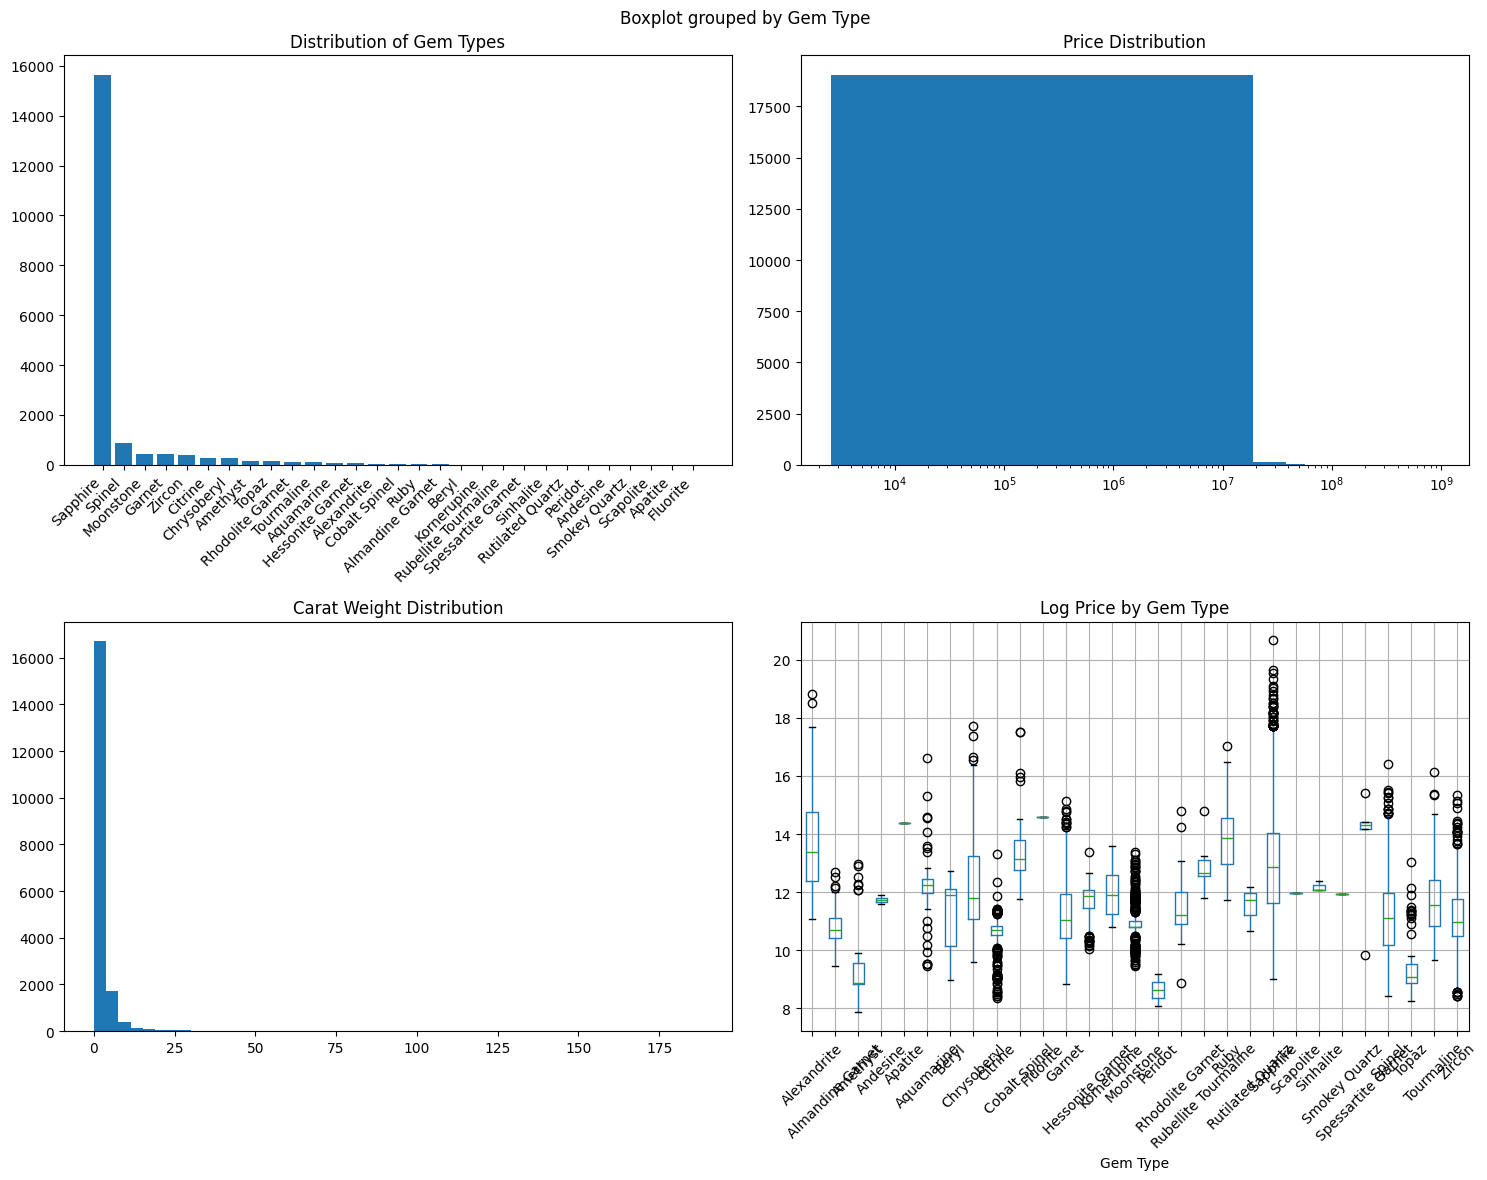

In [5]:
# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Distribution of Gem Types
gem_counts = df['Gem Type'].value_counts()
axes[0, 0].bar(gem_counts.index, gem_counts.values)
axes[0, 0].set_title('Distribution of Gem Types')
axes[0, 0].set_xticklabels(gem_counts.index, rotation=45, ha='right')

# Plot 2: Price Distribution (log scale)
axes[0, 1].hist(df['Asking Price (LKR)'], bins=50)
axes[0, 1].set_title('Price Distribution')
axes[0, 1].set_xscale('log')

# Plot 3: Carat Weight Distribution
axes[1, 0].hist(df['Carat Weight (ct)'], bins=50)
axes[1, 0].set_title('Carat Weight Distribution')

# Plot 4: Box Plot of log(Price) by Gem Type
df.boxplot(column='log_price', by='Gem Type', ax=axes[1, 1], rot=45)
axes[1, 1].set_title('Log Price by Gem Type')

plt.tight_layout()
plt.show()

## 5. Data Preparation

Prepare the data for modeling:
- Split features and target
- Create train/test split
- Set up preprocessing pipeline

In [6]:
# Identify numeric and categorical columns
numeric_features = [
    'Carat Weight (ct)', 'Length_mm', 'Width_mm', 'Depth_mm',
    'LW_Ratio', 'DepthPct'
]
numeric_features = [col for col in numeric_features if col in df.columns]

categorical_features = [
    'Gem Type', 'Cut/Shape', 'Colour', 'Clarity', 
    'Treatments', 'Certification Status'
]
categorical_features = [col for col in categorical_features if col in df.columns]

# Create feature matrix X and target vector y
X = df[numeric_features + categorical_features]
y = df['Asking Price (LKR)']
y_log = df['log_price']

# Check if stratification is possible (need at least 2 samples per class)
if 'Gem Type' in df.columns:
    gem_counts = df['Gem Type'].value_counts()
    can_stratify = gem_counts.min() >= 2
    stratify_by = df['Gem Type'].values if can_stratify else None
    if not can_stratify:
        print("Warning: Some gem types have too few samples for stratification.")
        print("Minimum samples per type:", gem_counts.min())
        print("Will perform regular random split instead.")
else:
    stratify_by = None

# Create train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, 
    stratify=stratify_by
)

# Split the log-transformed target using the same indices
train_idx = y_train.index
test_idx = y_test.index
y_log_train = y_log[train_idx]
y_log_test = y_log[test_idx]

# Create preprocessing pipelines with imputation
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("\nDataset Statistics:")
print("------------------")
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nFeatures being used:")
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Check for missing values
print("\nMissing values in training set:")
print(X_train.isnull().sum())

if 'Gem Type' in df.columns:
    print("\nGem Type Distribution:")
    print("Training set:", pd.Series(X_train['Gem Type'].value_counts()).to_dict())
    print("Test set:", pd.Series(X_test['Gem Type'].value_counts()).to_dict())

Minimum samples per type: 1
Will perform regular random split instead.

Dataset Statistics:
------------------
Training set shape: (15383, 12)
Test set shape: (3846, 12)

Features being used:
Numeric features: ['Carat Weight (ct)', 'Length_mm', 'Width_mm', 'Depth_mm', 'LW_Ratio', 'DepthPct']
Categorical features: ['Gem Type', 'Cut/Shape', 'Colour', 'Clarity', 'Treatments', 'Certification Status']

Missing values in training set:
Carat Weight (ct)       0
Length_mm               0
Width_mm                0
Depth_mm                0
LW_Ratio                0
DepthPct                0
Gem Type                0
Cut/Shape               0
Colour                  0
Clarity                 0
Treatments              0
Certification Status    0
dtype: int64

Gem Type Distribution:
Training set: {'Sapphire': 12482, 'Spinel': 709, 'Garnet': 366, 'Moonstone': 349, 'Zircon': 329, 'Citrine': 233, 'Chrysoberyl': 207, 'Amethyst': 137, 'Topaz': 121, 'Rhodolite Garnet': 103, 'Tourmaline': 85, 'Aquamarine

## 6. Model Training and Evaluation

We'll train two global models:
1. Direct price prediction
2. Log-transformed price prediction

In [7]:
# Create model pipelines
model_a = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

model_b = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

# Train models
print("Training Model A (direct price)...")
model_a.fit(X_train, y_train)

print("Training Model B (log price)...")
model_b.fit(X_train, y_log_train)

# Make predictions
y_pred_a = model_a.predict(X_test)
y_pred_b = np.expm1(model_b.predict(X_test))

# Calculate metrics
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    rmsle = np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'RMSLE': rmsle, 'R²': r2}

print("\nModel A Metrics:")
metrics_a = calculate_metrics(y_test, y_pred_a)
for metric, value in metrics_a.items():
    print(f"{metric}: {value:,.2f}")

print("\nModel B Metrics:")
metrics_b = calculate_metrics(y_test, y_pred_b)
for metric, value in metrics_b.items():
    print(f"{metric}: {value:,.2f}")

Training Model A (direct price)...
Training Model B (log price)...

Model A Metrics:
MAE: 721,163.92
RMSE: 4,910,034.11
RMSLE: 0.60
R²: 0.49

Model B Metrics:
MAE: 632,837.64
RMSE: 3,377,556.50
RMSLE: 0.54
R²: 0.76


In [8]:
# Compare model performances
print("\nModel Comparison:")
print("-" * 50)
print(f"Model A (Direct Prediction) RMSLE: {metrics_a['RMSLE']:,.4f}")
print(f"Model B (Log-transformed) RMSLE: {metrics_b['RMSLE']:,.4f}")
print("\nRecommended Model:", "B (Log-transformed)" if metrics_b['RMSLE'] < metrics_a['RMSLE'] else "A (Direct)")
print("-" * 50)

# Additional metrics comparison
metrics_comparison = pd.DataFrame({
    'Model A (Direct)': metrics_a,
    'Model B (Log-transformed)': metrics_b
}).round(4)
print("\nDetailed Metrics Comparison:")
print(metrics_comparison)


Model Comparison:
--------------------------------------------------
Model A (Direct Prediction) RMSLE: 0.5973
Model B (Log-transformed) RMSLE: 0.5358

Recommended Model: B (Log-transformed)
--------------------------------------------------

Detailed Metrics Comparison:
       Model A (Direct)  Model B (Log-transformed)
MAE        7.211639e+05               6.328376e+05
RMSE       4.910034e+06               3.377556e+06
RMSLE      5.973000e-01               5.358000e-01
R²         4.853000e-01               7.564000e-01


## 7. Visualize Predictions

Plot predicted vs actual prices for both models:

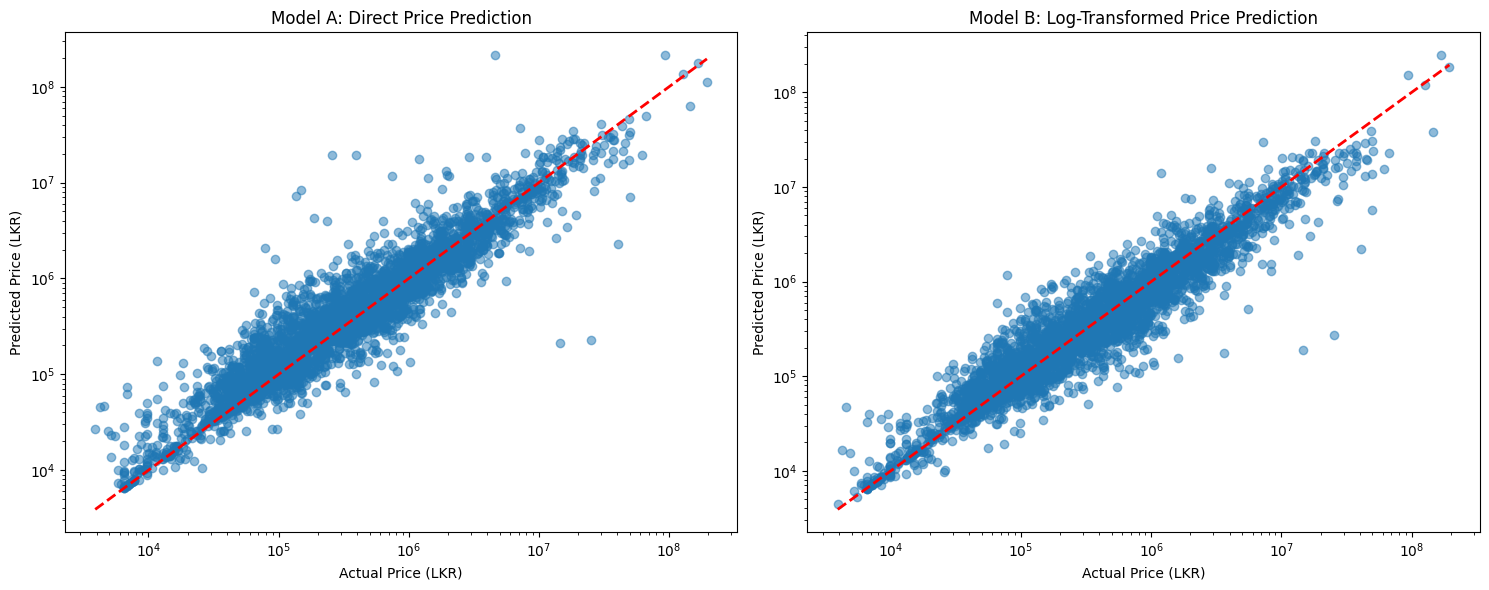

In [9]:
# Create scatter plots for both models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Model A: Direct Price Prediction
ax1.scatter(y_test, y_pred_a, alpha=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Price (LKR)')
ax1.set_ylabel('Predicted Price (LKR)')
ax1.set_title('Model A: Direct Price Prediction')
ax1.set_xscale('log')
ax1.set_yscale('log')

# Model B: Log-Transformed Price Prediction
ax2.scatter(y_test, y_pred_b, alpha=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Price (LKR)')
ax2.set_ylabel('Predicted Price (LKR)')
ax2.set_title('Model B: Log-Transformed Price Prediction')
ax2.set_xscale('log')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

## 8. Model Tuning

Perform grid search cross-validation on the better performing model:

In [10]:
# Create a parameter grid
param_grid = {
    'regressor__n_estimators': [200, 400],
    'regressor__max_depth': [None, 12, 20],
    'regressor__min_samples_leaf': [1, 3]
}

# Select the better model based on RMSLE
better_model = model_b if metrics_b['RMSLE'] < metrics_a['RMSLE'] else model_a
y_tune = y_log_train if metrics_b['RMSLE'] < metrics_a['RMSLE'] else y_train

# Perform grid search
print("Performing grid search (this may take a while)...")
grid_search = GridSearchCV(
    better_model, param_grid, cv=3, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_tune)

print("\nBest parameters:", grid_search.best_params_)
print("Best CV score:", -grid_search.best_score_)

Performing grid search (this may take a while)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 400}
Best CV score: 0.5331262015557936


## 9. Per-Gem-Type Analysis

Train individual models for each gem type:

In [11]:
# Initialize dictionary to store per-type models and metrics
gem_type_models = {}
gem_type_metrics = {}

# Train a model for each gem type
for gem_type in df['Gem Type'].unique():
    print(f"\nTraining model for {gem_type}...")
    
    # Filter data for this gem type
    mask_train = X_train['Gem Type'] == gem_type
    mask_test = X_test['Gem Type'] == gem_type
    
    if mask_train.sum() < 10:  # Skip if too few samples
        print(f"Skipping {gem_type} - insufficient samples")
        continue
    
    # Create and train model
    # Remove 'regressor__' prefix from parameters
    rf_params = {k.replace('regressor__', ''): v for k, v in grid_search.best_params_.items()}
    
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(
            **rf_params,
            random_state=42
        ))
    ])
    
    # Train on log prices
    model.fit(X_train[mask_train], y_log_train[mask_train])
    gem_type_models[gem_type] = model
    
    # Make predictions and calculate metrics
    y_pred = np.expm1(model.predict(X_test[mask_test]))
    metrics = calculate_metrics(y_test[mask_test], y_pred)
    gem_type_metrics[gem_type] = {
        'n_samples': mask_test.sum(),
        **metrics
    }

# Create a summary DataFrame
metrics_df = pd.DataFrame.from_dict(gem_type_metrics, orient='index')
print("\nPer-Gem-Type Performance Metrics:")
print(metrics_df.round(2))


Training model for Sapphire...

Training model for Zircon...

Training model for Moonstone...

Training model for Cobalt Spinel...

Training model for Rhodolite Garnet...

Training model for Aquamarine...

Training model for Alexandrite...

Training model for Chrysoberyl...

Training model for Beryl...
Skipping Beryl - insufficient samples

Training model for Amethyst...

Training model for Almandine Garnet...

Training model for Spinel...

Training model for Garnet...

Training model for Rubellite Tourmaline...
Skipping Rubellite Tourmaline - insufficient samples

Training model for Tourmaline...

Training model for Peridot...
Skipping Peridot - insufficient samples

Training model for Spessartite Garnet...
Skipping Spessartite Garnet - insufficient samples

Training model for Topaz...

Training model for Citrine...

Training model for Smokey Quartz...
Skipping Smokey Quartz - insufficient samples

Training model for Kornerupine...
Skipping Kornerupine - insufficient samples

Trainin

## 10. Save Models and Export Results

Save the best performing model and preprocessor:

In [12]:
# Create outputs/models directory if it doesn't exist
import os
os.makedirs('../outputs/models', exist_ok=True)

# Save the best global model
if metrics_b['RMSLE'] < metrics_a['RMSLE']:
    print("Saving log-transformed global model...")
    joblib.dump(grid_search.best_estimator_, '../models/gem_price_global.pkl')
    model_type = "log-transformed"
else:
    print("Saving direct prediction global model...")
    joblib.dump(grid_search.best_estimator_, '../models/gem_price_global.pkl')
    model_type = "direct"

# Save per-gem-type models
if len(gem_type_models) > 0:
    print("Saving per-gem-type models...")
    joblib.dump(gem_type_models, '../models/gem_price_by_type.pkl')

# Create README with usage instructions
readme_content = f"""# Gem Price Prediction Models

## Model Files
- `gem_price_global.pkl`: Global {model_type} price prediction model
- `gem_price_by_type.pkl`: Individual models for each gem type

## Usage Example
```python
import joblib
import pandas as pd

# Load the model
model = joblib.load('outputs/models/gem_price_global.pkl')

# Prepare input data (must have same columns as training data)
features = {numeric_features + categorical_features}

# Make prediction
X_new = pd.DataFrame([your_data], columns=features)
prediction = model.predict(X_new)

# If using log-transformed model, transform back
if "{model_type}" == "log-transformed":
    prediction = np.expm1(prediction)
```

## Model Performance
Global model RMSLE: {min(metrics_a['RMSLE'], metrics_b['RMSLE']):.3f}
"""

with open('../models/README.md', 'w') as f:
    f.write(readme_content)

print("Model artifacts saved successfully in outputs/models directory!")

Saving log-transformed global model...
Saving per-gem-type models...
Model artifacts saved successfully in outputs/models directory!


## 11. Optional: Feature Importance Analysis

Visualize the most important features in the model:

In [13]:
def get_feature_importance(model):
    # Get feature names from preprocessor
    ct = model.named_steps['preprocessor']
    feature_names = (
        numeric_features +
        [f"{feat}_{val}" for feat, vals in 
         zip(categorical_features, 
             ct.named_transformers_['cat'].categories_) 
         for val in vals]
    )
    
    # Get feature importance
    importances = model.named_steps['regressor'].feature_importances_
    return pd.Series(importances, index=feature_names).sort_values(ascending=True)

# Plot feature importance
best_model = grid_search.best_estimator_
importance = get_feature_importance(best_model)
top_n = 20

plt.figure(figsize=(10, 8))
importance.tail(top_n).plot(kind='barh')
plt.title(f'Top {top_n} Most Important Features')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

AttributeError: 'Pipeline' object has no attribute 'categories_'

## 12. Optional: Error Analysis

Analyze the largest prediction errors:

In [ ]:
# Calculate errors
test_predictions = grid_search.predict(X_test)
if model_type == "log-transformed":
    test_predictions = np.expm1(test_predictions)

errors = pd.DataFrame({
    'Actual': y_test,
    'Predicted': test_predictions,
    'Absolute_Error': np.abs(y_test - test_predictions),
    'Relative_Error': np.abs((y_test - test_predictions) / y_test) * 100
})

# Add feature values
for col in X_test.columns:
    errors[col] = X_test[col].values

# Sort by absolute error
errors_sorted = errors.sort_values('Absolute_Error', ascending=False)

print("Top 10 Largest Prediction Errors:")
print(errors_sorted.head(10).round(2))

## Conclusion

This notebook has:
1. Built a robust gem price prediction model
2. Handled missing/optional columns gracefully
3. Compared direct vs log-transformed price prediction
4. Provided both global and per-gem-type models
5. Saved model artifacts for production use
6. Included feature importance and error analysis

The model can be improved by:
1. Collecting more data for underrepresented gem types
2. Adding interaction features
3. Trying other algorithms (e.g., XGBoost)
4. Incorporating domain expert feedback